In [1]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

In [2]:
data_path = "/home/riccardo/Documents/orbit/source/standalone/logs/rsl_rl/unitree_go1_jump/"

In [3]:
# results = data_path +"_test.bin"
results = data_path +"test.bin"
fail = data_path +"failed.bin"

In [4]:
data = joblib.load(results)
fail_data = joblib.load(fail)

In [5]:
data.shape

(2, 10000, 3)

In [6]:
failed_idx = np.nonzero(fail_data)[0]

In [7]:
des = data[0][:,:2]
des.shape

(10000, 2)

In [8]:
xmin, xmax = des[:,0].min(), des[:,0].max()

In [9]:
ymin, ymax = des[:,1].min(), des[:,1].max()

In [10]:
# des = data[0][:, :2][(abs(data[0][:, 1]) < 0.3) & (data[0][:, 0] >= 0)]
# des.shape

In [11]:
actual = data[1][:,:2]
actual.shape

(10000, 2)

In [12]:
# actual = data[1][:, :2][(abs(data[0][:, 1]) < 0.3) & (data[0][:, 0] >= 0)]
# actual.shape

In [13]:
err = np.linalg.norm(des - actual, axis=1)
err

array([0.15050684, 0.5321201 , 0.5240207 , ..., 0.0906932 , 0.00614022,
       0.01172646], dtype=float32)

In [14]:
failed_jump = des[failed_idx]

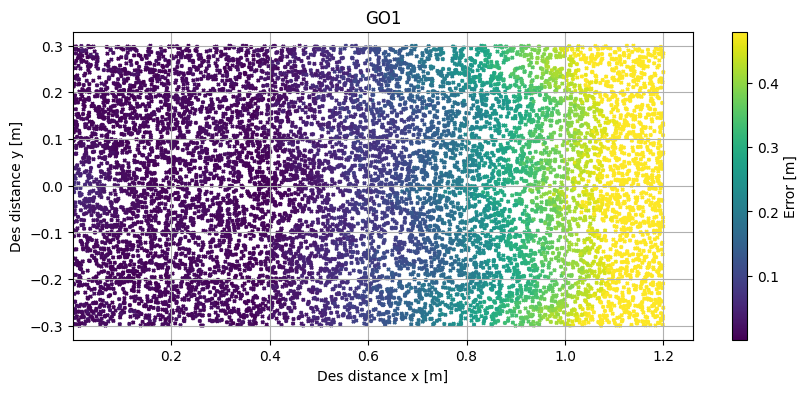

In [15]:
plt.figure(figsize=(10, 4))
plt.scatter(des[:, 0], des[:, 1], np.full(des[: , 1].shape, 5), vmax=0.48, marker='x', c=err, zorder=0)
# plt.scatter(failed_jump[:, 0], failed_jump[:, 1], np.full(failed_jump[: , 1].shape, 5), marker='x', color="red", zorder=1)
plt.xlim(xmin * 1.05, xmax * 1.05)
plt.ylim(ymin * 1.1, ymax * 1.1)
plt.grid()
plt.title("GO1")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path + "abs_err.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [16]:
idx = err <= 0.2

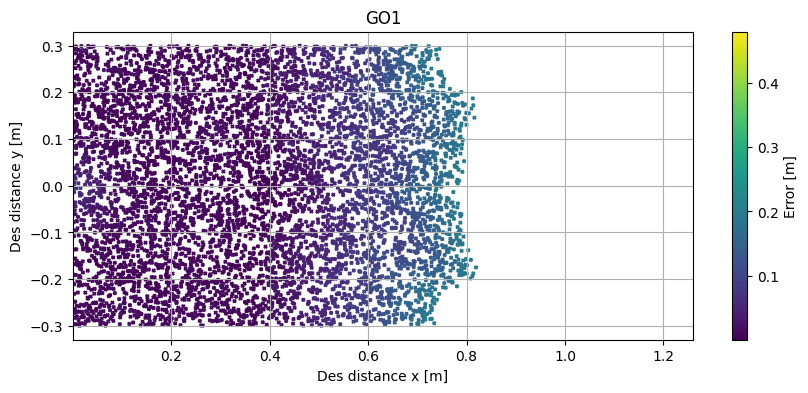

In [17]:
plt.figure(figsize=(10,4))
plt.scatter(des[:,0][idx],des[:,1][idx], np.full(des[: , 1].shape,5)[idx], vmax=0.48, marker='x', c=err[idx])
plt.grid()
plt.xlim(xmin*1.05,xmax*1.05)
plt.ylim(ymin*1.1,ymax*1.1)
plt.title("GO1")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err_filtered.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [18]:
des_dist = np.linalg.norm(des, axis=1)
des_dist

array([0.75828034, 1.1270916 , 1.0979656 , ..., 0.66242224, 0.37506902,
       0.35413197], dtype=float32)

In [19]:
actual_dist = np.linalg.norm(actual, axis=1)
actual_dist

array([0.6077773 , 0.59701484, 0.57550275, ..., 0.57187533, 0.37702718,
       0.36060482], dtype=float32)

In [20]:
np.linalg.norm([0.6,.3])

0.6708203932499369

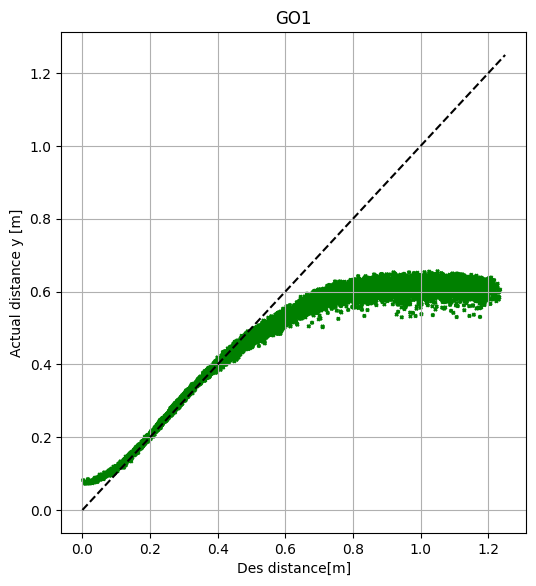

In [21]:

plt.figure(figsize=(6, 6.5))
plt.grid()
plt.scatter(des_dist,actual_dist, np.full(des_dist.shape,5), marker='x', alpha=1, color="green")
plt.scatter(des_dist[failed_idx],actual_dist[failed_idx], np.full(des_dist[failed_idx].shape,5), marker='x', alpha=1, color="red")
plt.title("GO1")
plt.plot([0.0,1.25],[0.0,1.25], '--', color="black")
# plt.colorbar(label="Error [m]")
plt.xlabel("Des distance[m]")
plt.ylabel("Actual distance y [m]")
plt.savefig(data_path+"diag_err.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [22]:
perc_err = err / des_dist
perc_err

array([0.19848444, 0.47211787, 0.47726512, ..., 0.13691147, 0.0163709 ,
       0.03311324], dtype=float32)

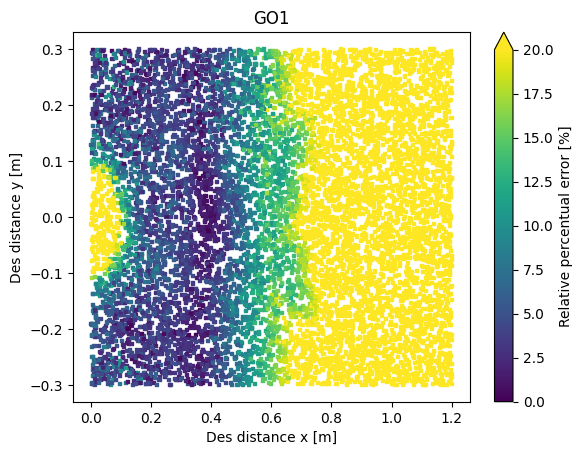

In [23]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=perc_err*100, vmin=0, vmax=20)
plt.colorbar(label="Relative percentual error [%]", extend='max')
plt.title("GO1")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"perc_err.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [24]:
data_path = "/home/riccardo/Documents/orbit/source/standalone/logs/rsl_rl/unitree_a1_jump/"

In [25]:
# results = data_path +"_test.bin"
results = data_path +"test.bin"
fail = data_path +"failed.bin"

In [26]:
data = joblib.load(results)
fail_data = joblib.load(fail)

In [27]:
data

array([[[ 0.29013062,  0.18661499,  0.5       ],
        [ 0.05851746, -0.0478363 ,  0.5       ],
        [ 0.8986969 , -0.01208496,  0.5       ],
        ...,
        [ 0.5281677 , -0.01504517,  0.5       ],
        [ 0.7924652 , -0.23468018,  0.5       ],
        [ 0.93626404, -0.02485657,  0.5       ]],

       [[ 0.3052826 ,  0.20233154,  0.50000226],
        [ 0.10778809, -0.07197571,  0.5000016 ],
        [ 0.69096375, -0.00495911,  0.4999977 ],
        ...,
        [ 0.5613556 , -0.01177979,  0.49999908],
        [ 0.6336212 , -0.16038513,  0.5000001 ],
        [ 0.69039917, -0.00784302,  0.49999705]]], dtype=float32)

In [28]:
data.shape

(2, 10000, 3)

In [29]:
failed_idx = np.nonzero(fail_data)[0]

In [30]:
des = data[0][:,:2]
des.shape

(10000, 2)

In [31]:
xmin, xmax = des[:,0].min(), des[:,0].max()

In [32]:
ymin, ymax = des[:,1].min(), des[:,1].max()

In [33]:
actual = data[1][:,:2]
actual.shape

(10000, 2)

In [34]:
err = np.linalg.norm(des - actual, axis=1)
err

array([0.021831  , 0.05486625, 0.20785534, ..., 0.03334812, 0.17536011,
       0.24645282], dtype=float32)

In [35]:
failed_jump = des[failed_idx]

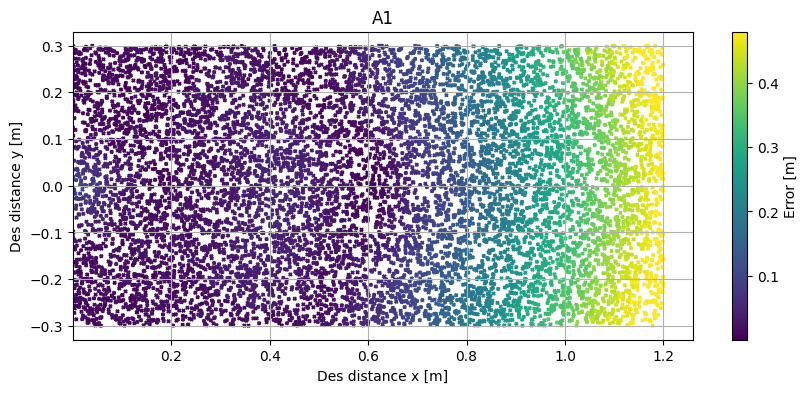

In [36]:
plt.figure(figsize=(10, 4))
plt.scatter(des[:, 0], des[:, 1], np.full(des[: , 1].shape, 5), vmax=0.48, marker='x', c=err, zorder=0)
# plt.scatter(failed_jump[:, 0], failed_jump[:, 1], np.full(failed_jump[: , 1].shape, 5), marker='x', color="red", zorder=1)
plt.xlim(xmin * 1.05, xmax * 1.05)
plt.ylim(ymin * 1.1, ymax * 1.1)
plt.grid()
plt.title("A1")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path + "abs_err.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [37]:
idx = err <= 0.2

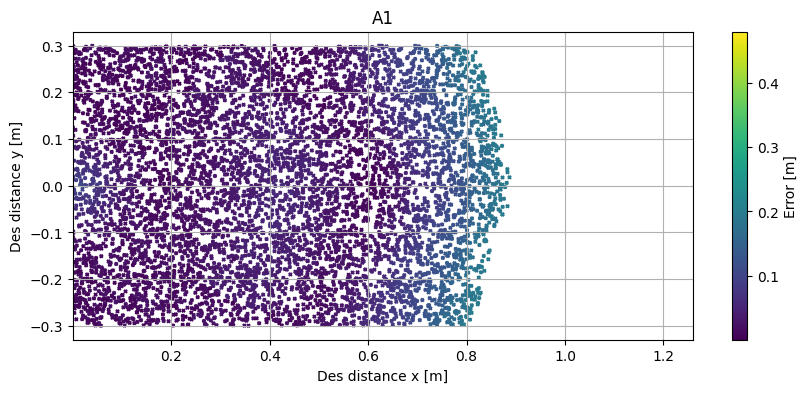

In [38]:
plt.figure(figsize=(10,4))
plt.scatter(des[:,0][idx],des[:,1][idx], np.full(des[: , 1].shape,5)[idx], vmax=0.48, marker='x', c=err[idx])
plt.grid()
plt.xlim(xmin*1.05,xmax*1.05)
plt.ylim(ymin*1.1,ymax*1.1)
plt.title("A1")
plt.colorbar(label="Error [m]")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"abs_err_filtered.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [39]:
des_dist = np.linalg.norm(des, axis=1)
des_dist

array([0.3449651 , 0.07558177, 0.89877814, ..., 0.52838194, 0.8264841 ,
       0.93659395], dtype=float32)

In [40]:
actual_dist = np.linalg.norm(actual, axis=1)
actual_dist

array([0.36624515, 0.12961008, 0.69098157, ..., 0.56147915, 0.6536048 ,
       0.6904437 ], dtype=float32)

In [41]:
np.linalg.norm([0.6,.3])

0.6708203932499369

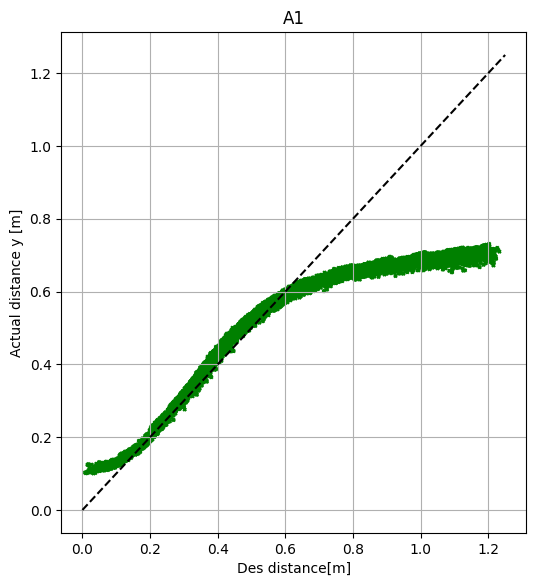

In [42]:

plt.figure(figsize=(6, 6.5))
plt.grid()
plt.scatter(des_dist,actual_dist, np.full(des_dist.shape,5), marker='x', alpha=1, color="green")
plt.scatter(des_dist[failed_idx],actual_dist[failed_idx], np.full(des_dist[failed_idx].shape,5), marker='x', alpha=1, color="red")
plt.title("A1")
plt.plot([0.0,1.25],[0.0,1.25], '--', color="black")
# plt.colorbar(label="Error [m]")
plt.xlabel("Des distance[m]")
plt.ylabel("Actual distance y [m]")
plt.savefig(data_path+"diag_err.pdf", dpi=500, bbox_inches='tight')
plt.show()

In [43]:
perc_err = err / des_dist
perc_err

array([0.06328466, 0.7259191 , 0.23126435, ..., 0.06311367, 0.21217602,
       0.2631373 ], dtype=float32)

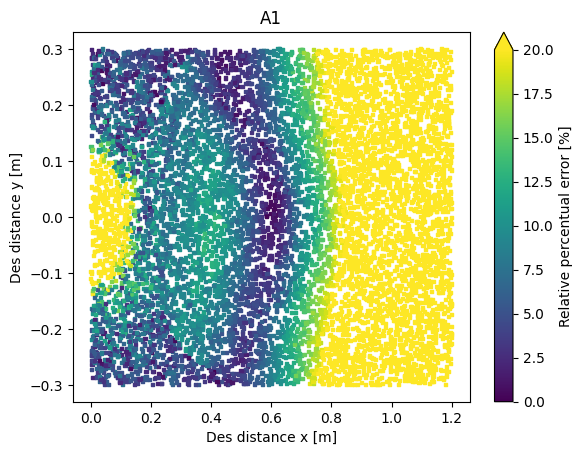

In [44]:
plt.scatter(des[:,0],des[:,1], np.full(des[: , 1].shape,5), marker='s', c=perc_err*100, vmin=0, vmax=20)
plt.colorbar(label="Relative percentual error [%]", extend='max')
plt.title("A1")
plt.xlabel("Des distance x [m]")
plt.ylabel("Des distance y [m]")
plt.savefig(data_path+"perc_err.pdf", dpi=500, bbox_inches='tight')
plt.show()